# Biquadratic Coupling Demo 1

Example taken from Ubermag 
https://ubermag.github.io/examples/notebooks/rkky.html

But I reduced the M_sat of a layer by a half to better demonstrate the effect of the exchange coupling. 


In [1]:
from magnumnp import *
import torch
from matplotlib import pyplot as plt
import numpy as np


%config InlineBackend.figure_format = 'retina'

torch.set_default_dtype(torch.float32)

2024-03-27 12:00:56  magnum.np:INFO magnum.np 1.1.5


In [8]:
sigma2 = np.array([0, -0.1, -0.05, -0.01])
sigma2 = sigma2 * 2

for sigma2_ in sigma2:
        Timer.enable()

        J_rkky = sigma2_

        # initialize mesh
        n  = (20, 20, 5)
        dx = (3e-9, 3e-9, 2e-9)
        mesh = Mesh(n, dx)
        state = State(mesh, device="cuda")

        state.material = {
                "alpha": 1
                }

        domain1 = state.zeros(n, dtype=torch.bool)
        domain2 = state.zeros(n, dtype=torch.bool)
        domain1[:,:,0:2] = True
        domain2[:,:,3:5] = True

        # Set initial magnetization
        state.m = state.Constant([0, 0, 0])
        size_ref = state.m[domain1].shape
        state.m[domain1] = state.Tensor([-0.99, 0.01, 0])
        state.m[domain2] = state.Tensor([0.99, 0.01, 0])


        Ku = state.Constant([0.0]) 
        Ku[domain1] = 1e5
        Ku[domain2] = 1e5


        A = state.Constant([0.0]) 
        A[domain1] = 1e-12
        A[domain2] = 1e-12


        Ms = state.Constant([0.0])
        Ms[domain1] = 8e6
        Ms[domain2] = 4e6

        Ku_axis = state.Constant([1, 0, 0])
        Ku_axis[domain1] = state.Tensor([1, 0, 0])
        Ku_axis[domain2] = state.Tensor([1, 0, 0])


        state.material['Ms'] = Ms
        state.material['A'] = A
        state.material['Ku'] = Ku
        state.material['Ku_axis'] = Ku_axis


        exchange1 = ExchangeField(domain1)
        exchange2 = ExchangeField(domain2)
        rkky      = BiquadraticField(J_rkky, "z", 1, 3)
        aniso     = UniaxialAnisotropyField()
        demag    = DemagField()


        llg = LLGSolver([demag, exchange1, exchange2, aniso, rkky])
        llg.relax(state, silent=True)


        external = ExternalField(TimeInterpolator(state, {0.0e-9: [0.0, 0.0, 0.0],
                                                        1.0e-9: [0.0, 0.0, 0.0],
                                                        3.5e-9: [0, 0.0, 20/constants.mu_0],
                                                        8.5e-9: [0, 0.0, -20/constants.mu_0],
                                                        13.5e-9: [0, 0.0, 20/constants.mu_0]}))

        llg = LLGSolver([demag, aniso, exchange1, exchange2, external, rkky])
        logger = ScalarLogger("data/m.dat", ['t', external.h, 'm'])
        eps = 1e-15
        with open("data/domain1_BQ.dat", "w") as f:
                with open("data/domain2_BQ.dat", "w") as g:
                        while state.t < 13.5e-9-eps:
                                llg.step(state, 1e-10, silent=True)
                                logger << state

                                domain1_ = state.m[domain1].average()
                                domain2_ = state.m[domain2].average()

                                f.write(f"{state.t} {domain1_[0].item()} {domain1_[1].item()} {domain1_[2].item()}\n")
                                g.write(f"{state.t} {domain2_[0].item()} {domain2_[1].item()} {domain2_[2].item()}\n")

        Timer.print_report()
        data = np.loadtxt("data/m.dat")
        B = data[:,3]*4*np.pi*1e-7

        data = np.loadtxt("data/domain1_BQ.dat")
        mz1 = data[:,3]

        data = np.loadtxt("data/domain2_BQ.dat")
        mz2 = data[:,3]

        M_total = (mz1*2/3 + mz2*1/3)

        np.save(f"ref/hysteresis_Mz_sigma2_{sigma2_}.npy", M_total)
        np.save(f"ref/hysteresis_Bz_sigma2_{sigma2_}.npy", B)


2024-03-27 12:15:52  magnum.np:INFO [State] running on device: cuda (dtype = float32)
2024-03-27 12:15:52  magnum.np:INFO [Mesh] 20x20x5 (size= 3e-09 x 3e-09 x 2e-09)
2024-03-27 12:15:52  magnum.np:INFO [LLGSolver] using RKF45 solver (atol = 1e-05)


2024-03-27 12:15:52  magnum.np:INFO [DEMAG]: Time calculation of demag kernel = 0.08278703689575195 s
2024-03-27 12:15:56  magnum.np:INFO [LLGSolver] using RKF45 solver (atol = 1e-05)
2024-03-27 12:16:46  magnum.np:INFO [State] running on device: cuda (dtype = float32)
2024-03-27 12:16:46  magnum.np:INFO [Mesh] 20x20x5 (size= 3e-09 x 3e-09 x 2e-09)
2024-03-27 12:16:46  magnum.np:INFO [LLGSolver] using RKF45 solver (atol = 1e-05)
2024-03-27 12:16:46  magnum.np:INFO [DEMAG]: Time calculation of demag kernel = 0.07997322082519531 s



TIMER REPORT
Operation                        No of calls    Avg time [ms]    Total time [s]
-----------------------------  -------------  ---------------  ----------------
LLGSolver.relax                            5    32098.8              160.494
    DemagField.h                      103889        0.755767          78.5159
    ExchangeField.h                   207778        0.115935          24.0888
    UniaxialAnisotropyField.h         103889        0.0800749          8.3189
    BiquadraticField.h                102672        0.144702          14.8568
LLGSolver.step                           675      997.392            673.239
    DemagField.h                      393018        0.622368         244.602
    UniaxialAnisotropyField.h         393018        0.0682853         26.8374
    ExchangeField.h                   786036        0.0974957         76.6351
    ExternalField.h                   393018        0.377097         148.206
    BiquadraticField.h                393018      

2024-03-27 12:17:55  magnum.np:INFO [LLGSolver] using RKF45 solver (atol = 1e-05)
2024-03-27 12:21:48  magnum.np:INFO [State] running on device: cuda (dtype = float32)
2024-03-27 12:21:48  magnum.np:INFO [Mesh] 20x20x5 (size= 3e-09 x 3e-09 x 2e-09)
2024-03-27 12:21:48  magnum.np:INFO [LLGSolver] using RKF45 solver (atol = 1e-05)
2024-03-27 12:21:48  magnum.np:INFO [DEMAG]: Time calculation of demag kernel = 0.08362627029418945 s



TIMER REPORT
Operation                        No of calls    Avg time [ms]    Total time [s]
-----------------------------  -------------  ---------------  ----------------
LLGSolver.relax                            6    38154.8              228.929
    DemagField.h                      166996        0.65824          109.923
    ExchangeField.h                   333992        0.104844          35.0172
    UniaxialAnisotropyField.h         166996        0.0770125         12.8608
    BiquadraticField.h                165330        0.139954          23.1387
LLGSolver.step                           810     1118.76             906.192
    DemagField.h                      573468        0.579208         332.157
    UniaxialAnisotropyField.h         573468        0.0672158         38.5461
    ExchangeField.h                  1146936        0.0945438        108.436
    ExternalField.h                   573468        0.309408         177.436
    BiquadraticField.h                573468        

2024-03-27 12:22:18  magnum.np:INFO [LLGSolver] using RKF45 solver (atol = 1e-05)
2024-03-27 12:24:14  magnum.np:INFO [State] running on device: cuda (dtype = float32)
2024-03-27 12:24:14  magnum.np:INFO [Mesh] 20x20x5 (size= 3e-09 x 3e-09 x 2e-09)
2024-03-27 12:24:14  magnum.np:INFO [LLGSolver] using RKF45 solver (atol = 1e-05)
2024-03-27 12:24:14  magnum.np:INFO [DEMAG]: Time calculation of demag kernel = 0.08246946334838867 s



TIMER REPORT
Operation                        No of calls    Avg time [ms]    Total time [s]
-----------------------------  -------------  ---------------  ----------------
LLGSolver.relax                            7    36936.6                258.556
    DemagField.h                      194574        0.633967           123.353
    ExchangeField.h                   389148        0.102398            39.8481
    UniaxialAnisotropyField.h         194574        0.0763208           14.85
    BiquadraticField.h                192558        0.13886             26.7385
LLGSolver.step                           945     1082.54              1023
    DemagField.h                      664974        0.565598           376.108
    UniaxialAnisotropyField.h         664974        0.0668169           44.4315
    ExchangeField.h                  1329948        0.0935385          124.401
    ExternalField.h                   664974        0.288711           191.985
    BiquadraticField.h                

2024-03-27 12:24:20  magnum.np:INFO [LLGSolver] using RKF45 solver (atol = 1e-05)



TIMER REPORT
Operation                        No of calls    Avg time [ms]    Total time [s]
-----------------------------  -------------  ---------------  ----------------
LLGSolver.relax                            8    33046.5              264.372
    DemagField.h                      199946        0.630272         126.02
    ExchangeField.h                   399892        0.101991          40.7855
    UniaxialAnisotropyField.h         199946        0.0762064         15.2372
    BiquadraticField.h                197772        0.138667          27.4245
LLGSolver.step                          1080      997.64            1077.45
    DemagField.h                      706524        0.561205         396.504
    UniaxialAnisotropyField.h         706524        0.0667215         47.1404
    ExchangeField.h                  1413048        0.0932667        131.79
    ExternalField.h                   706524        0.28183          199.119
    BiquadraticField.h                706524        0.1

0.0
-0.2
-0.1
-0.02


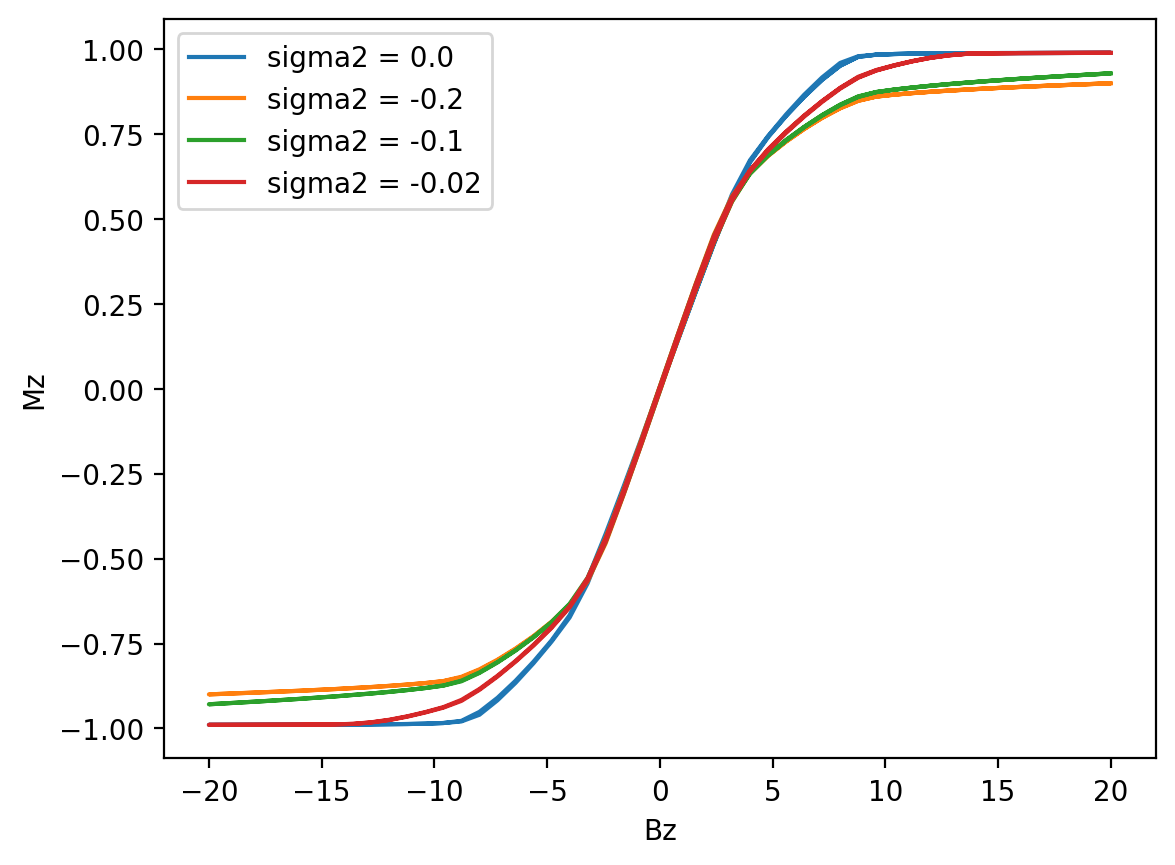

In [9]:
B = np.zeros((4, len(M_total)))
M = np.zeros((4, len(M_total)))



for i, sigma2_ in enumerate(sigma2):
        print(sigma2_)
        B[i] = np.load(f"ref/hysteresis_Bz_sigma2_{sigma2_}.npy")
        M[i] = np.load(f"ref/hysteresis_Mz_sigma2_{sigma2_}.npy")

        
        plt.plot(B[i], M[i], label = f"sigma2 = {sigma2[i]}")

plt.xlabel("Bz")
plt.ylabel("Mz")
plt.legend()

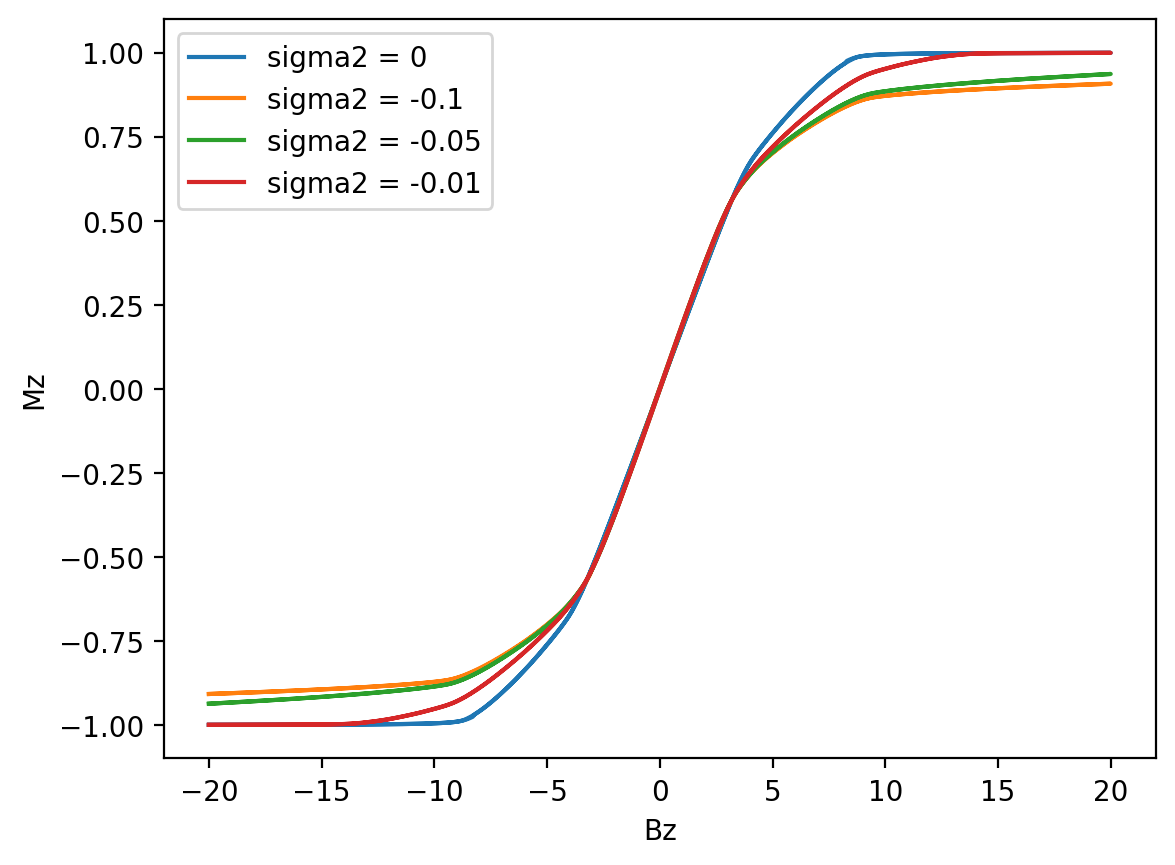

In [10]:
sigma2_oommf = [0, -0.1, -0.05, -0.01]

B_oommf = np.zeros((4, 801))
M_oommf = np.zeros((4, 801))

for i, sigma2_ in enumerate(sigma2_oommf):
    B_oommf[i] = np.load(f"ref/oommf_hysteresis_Bz_sigma2_{sigma2_}.npy")/1000
    M_oommf[i] = np.load(f"ref/oommf_hysteresis_mz_sigma2_{sigma2_}.npy")

    plt.plot(B_oommf[i], M_oommf[i], label = f"sigma2 = {sigma2_oommf[i]}")

plt.xlabel("Bz")
plt.ylabel("Mz")
plt.legend()

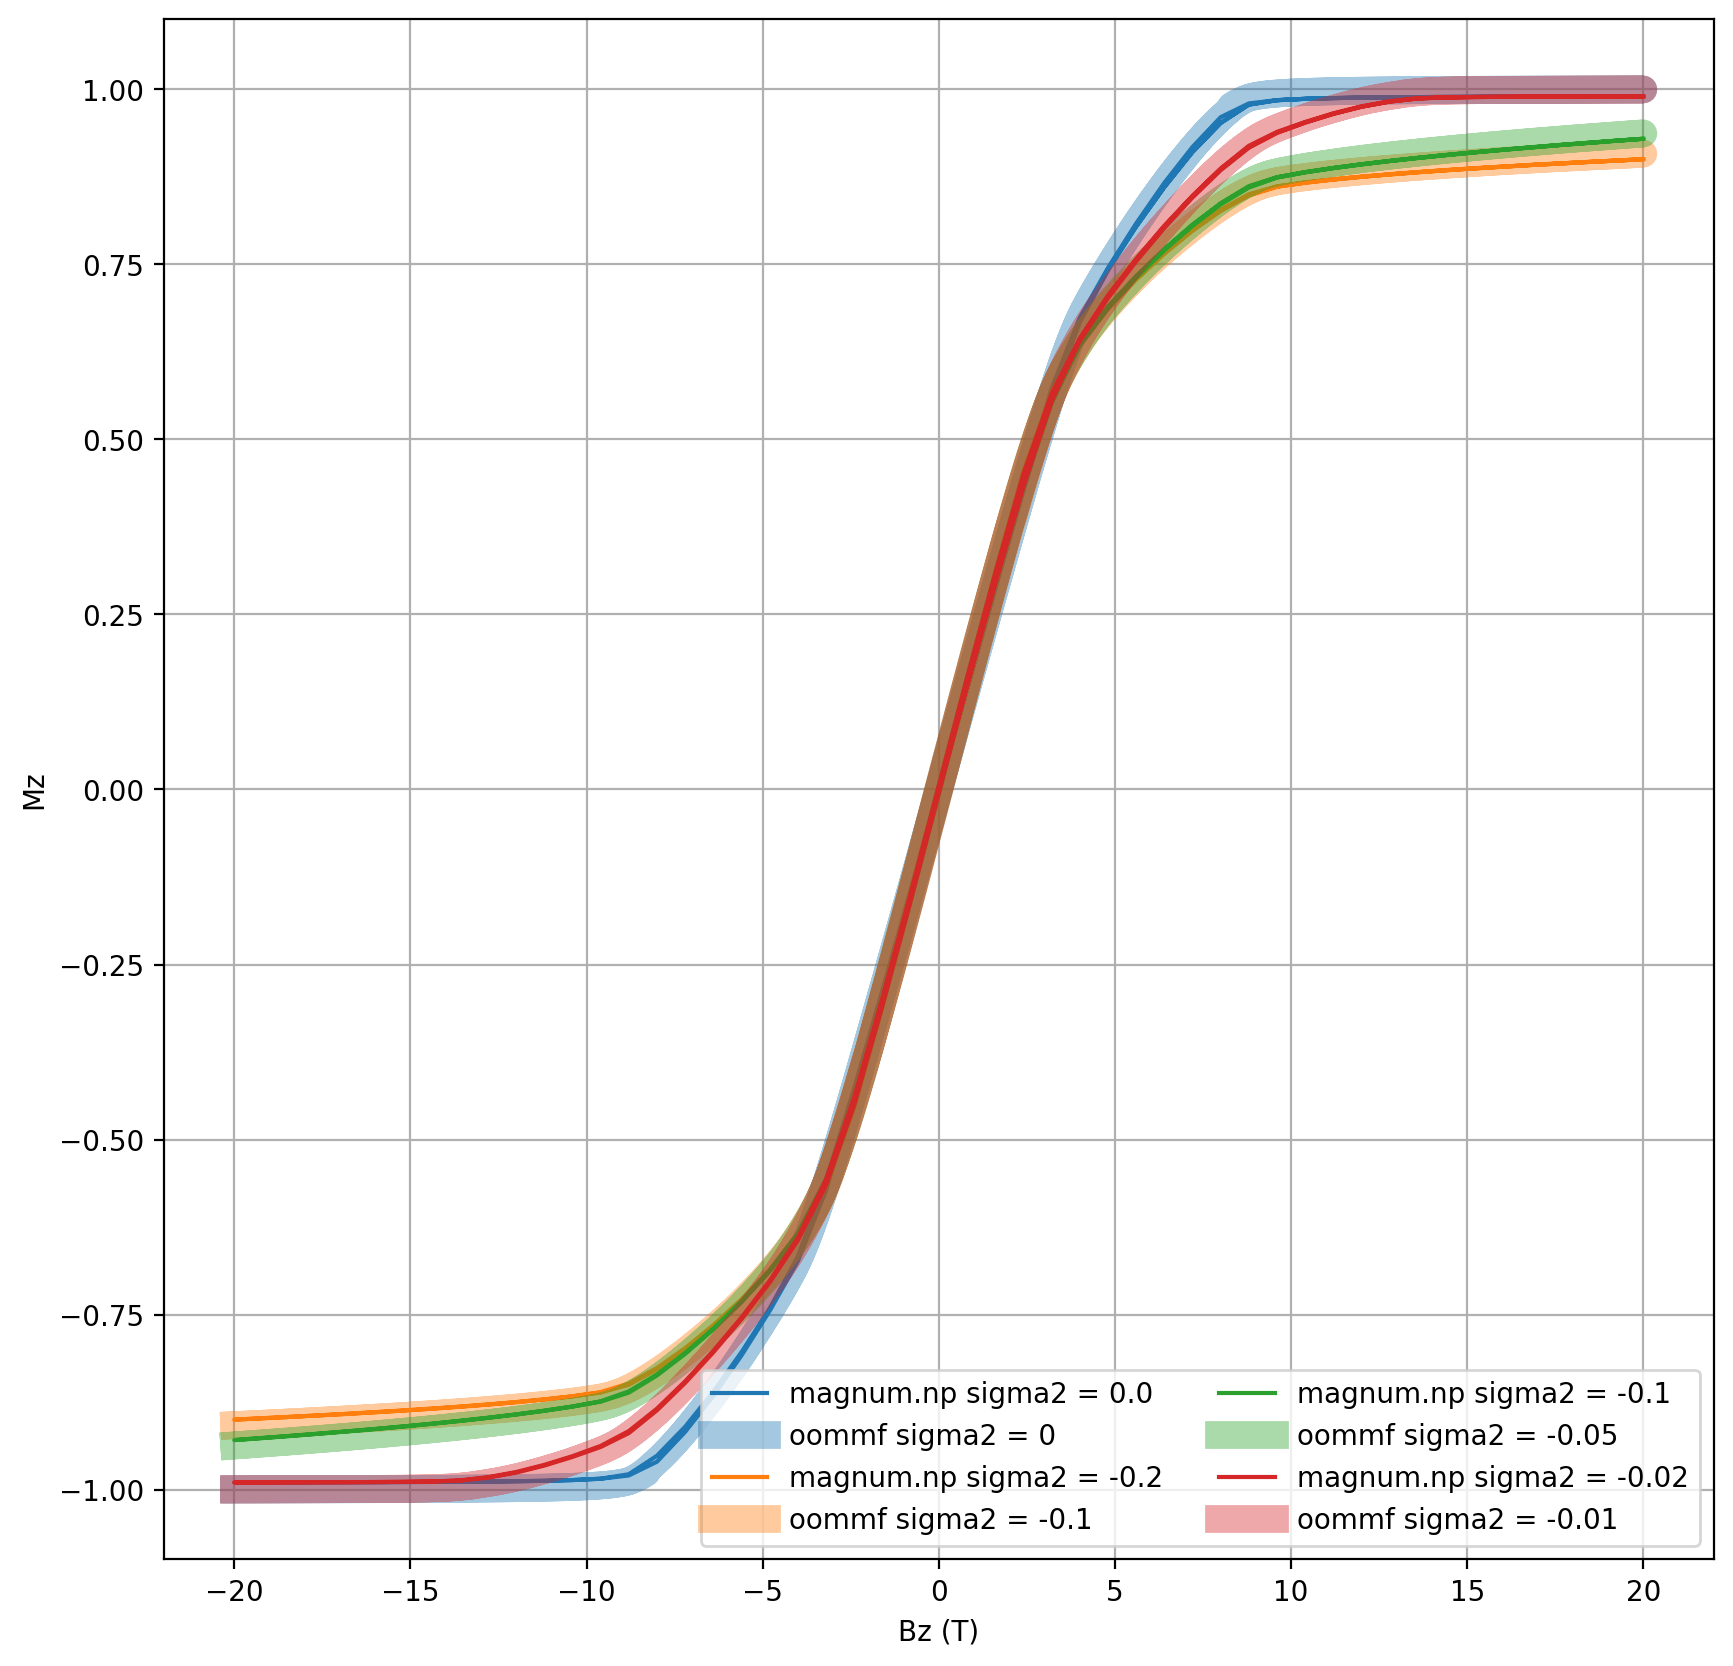

In [11]:
fig, ax = plt.subplots(figsize=(10, 10))
cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

for i in range(4):
    ax.plot(B[i], M[i], label = f"magnum.np sigma2 = {sigma2[i]}", color = cycle[i])
    ax.plot(B_oommf[i], M_oommf[i], alpha = 0.4,label = f"oommf sigma2 = {sigma2_oommf[i]}", color = cycle[i], linewidth = 10)

ax.set_xlabel("Bz (T)")
ax.set_ylabel("Mz")
ax.legend(ncol = 2)
ax.grid()